# Grupo 10
Javier Alejandro Viasus Florez  
Samuel Reyes Benavides  
Juan Sebastian Rodriguez Casas

La estructura y la teoria se baso en el libro de nuestra bibliografia (Haykin, S. (1999). Neural Networks and Learning Machines. Third Edition)

# Mecánica estadística

La mecánica estadística es una rama de la física que utiliza métodos probabilísticos para describir sistemas con un gran número de partículas. En lugar de analizar cada partícula individualmente, el comportamiento del sistema se describe mediante distribuciones de probabilidad sobre los estados posibles del sistema.

Esta teoría conecta dos niveles de descripción:

Nivel microscópico: describe las propiedades individuales de las partículas, como posición, velocidad y energía.

Nivel macroscópico: describe propiedades observables como temperatura, presión o energía total.

La mecánica estadística permite explicar cómo las propiedades macroscópicas emergen del comportamiento colectivo de millones o billones de partículas.

Las Máquinas de Boltzmann se inspiran en la termodinámica para describir cómo se distribuye la energía en un sistema de neuronas.

# Microestados y macroestados

Un sistema físico puede encontrarse en muchos estados posibles.

## Microestado

Es la configuración exacta de todas las variables microscópicas del sistema, por ejemplo:
- posición de cada partícula
- velocidad de cada partícula

## Macroestado

Es la descripción del sistema mediante variables observables, como:
- temperatura
- presión
-volumen

El Concepto de EnergíaEn una BM, cada configuración de estados (neuronas encendidas o apagadas) tiene una función de energía. La idea es simple: queremos que los estados "correctos" o "aprendidos" tengan la energía más baja.La energía de un estado conjunto  v  (visibles) y  h  (ocultas) se define como:

$$E(v, h) = -\sum_{i} a_i v_i - \sum_{j} b_j h_j - \sum_{i,j} v_i w_{ij} h_j$$

La Distribución de BoltzmannLa probabilidad de que la red se encuentre en un estado específico depende de esa energía siguiendo la Ley de Boltzmann:

$$P(v, h) = \frac{e^{-E(v, h)}}{Z}$$

Donde  Z  es la Función de Partición, una constante de normalización que suma todas las configuraciones posibles (y que, curiosamente, es lo más difícil de calcular en la práctica)

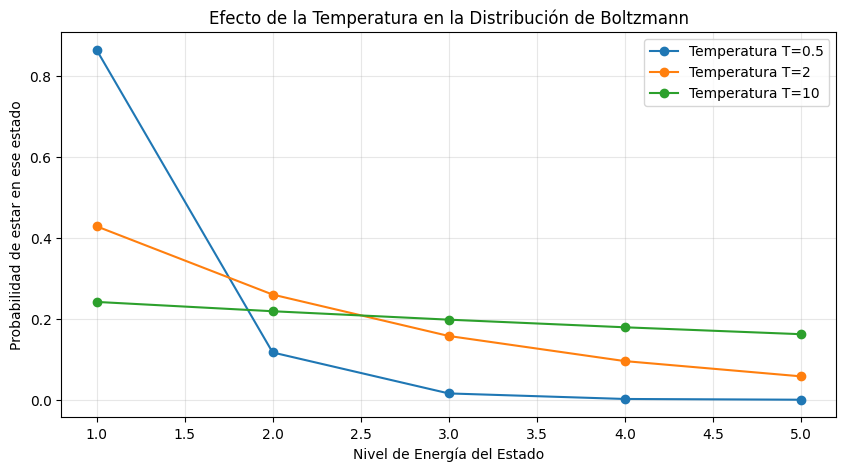

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def boltzmann_distribution(energy, T):
    # P(E) = exp(-E/T) / Z
    probabilities = np.exp(-energy / T)
    return probabilities / np.sum(probabilities)

# Definimos 5 estados con energías crecientes
energies = np.array([1, 2, 3, 4, 5])
temperatures = [0.5, 2, 10]

plt.figure(figsize=(10, 5))
for T in temperatures:
    probs = boltzmann_distribution(energies, T)
    plt.plot(energies, probs, '-o', label=f'Temperatura T={T}')

plt.title("Efecto de la Temperatura en la Distribución de Boltzmann")
plt.xlabel("Nivel de Energía del Estado")
plt.ylabel("Probabilidad de estar en ese estado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Cadenas de Markov

Una cadena de Markov es un modelo probabilístico que describe una secuencia de estados donde la probabilidad del siguiente estado depende únicamente del estado actual.

Esta propiedad se conoce como propiedad de Markov.

P(Xt+1​∣Xt​,Xt−1​,...,X0​)=P(Xt+1​∣Xt​)

Esto significa que el sistema no necesita conocer todo el pasado, sino únicamente su estado presente.

Una cadena de Markov está formada por:

Estados
Los posibles valores o configuraciones que puede tomar el sistema.

Probabilidades de transición
Las probabilidades de pasar de un estado a otro.

Estas probabilidades se organizan en una matriz de transición.

Secuencia de estados: [0, np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0)]


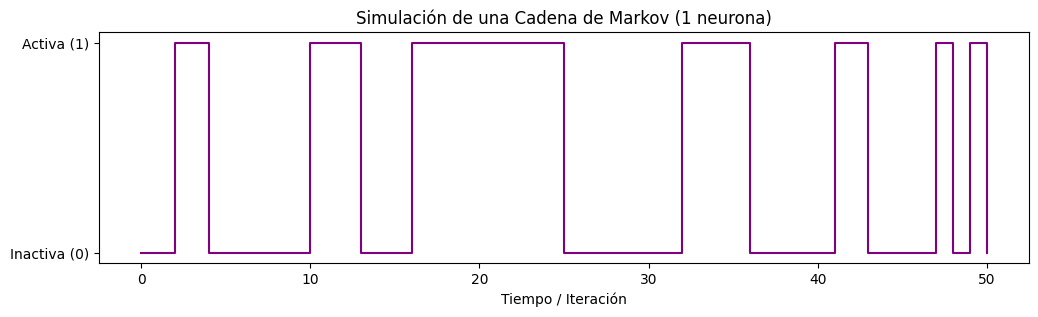

In [2]:
# Matriz de Transición: P(Estado_t+1 | Estado_t)
# [P(0->0), P(0->1)]
# [P(1->0), P(1->1)]
P = np.array([[0.8, 0.2],
              [0.3, 0.7]])

def simulate_markov_chain(steps, start_state=0):
    states = [start_state]
    current_state = start_state

    for _ in range(steps):
        # Elegimos el siguiente estado basado en las probabilidades de la matriz P
        next_state = np.random.choice([0, 1], p=P[current_state])
        states.append(next_state)
        current_state = next_state
    return states

# Simulamos 50 pasos de tiempo
history = simulate_markov_chain(50)

print(f"Secuencia de estados: {history}")

# Visualización simple
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 3))
plt.step(range(len(history)), history, where='post', color='purple')
plt.yticks([0, 1], ['Inactiva (0)', 'Activa (1)'])
plt.title("Simulación de una Cadena de Markov (1 neurona)")
plt.xlabel("Tiempo / Iteración")
plt.show()

# Metropolis, Recocido Simulado y Muestreo de Gibbs

En esta sección, se muestran tres algoritmos estocásticos usados para explorar espacios de probabilidad y optimizar funciones complejas:

- **Metropolis (MCMC)**
- **Recocido simulado**
- **Muestreo de Gibbs**

Cada sección incluye una explicación conceptual y una visualización del algoritmo en acción.


###Configuración de Entorno

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

def rng_from_seed(seed: int) -> np.random.Generator:
    return np.random.default_rng(int(seed))

def autocorr_coeffs(x: np.ndarray, max_lag: int = 40) -> np.ndarray:
    """
    Autocorrelación muestral para lags 1..max_lag.
    Útil como diagnóstico simple de mezcla en cadenas MCMC.
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()

    max_lag = int(max_lag)
    ac = np.empty(max_lag, dtype=float)

    for lag in range(1, max_lag + 1):
        a = x[:-lag]
        b = x[lag:]
        den = np.sqrt(np.dot(a, a) * np.dot(b, b))
        ac[lag - 1] = (np.dot(a, b) / den) if den > 0 else np.nan

    return ac

def sigmoid(z):
    z = np.asarray(z, dtype=float)
    return 1.0 / (1.0 + np.exp(-z))

print('Entorno listo.')

Entorno listo.


## Marco conceptual: distribución de Gibbs y paisaje de energía

En diversos problemas (incluidos algunos enfoques probabilísticos en redes neuronales) aparece una distribución objetivo de la forma **Gibbs**:

$$p(x) \propto \exp\big(-E(x)/T\big), \qquad T>0.$$

- $E(x)$: energía o función de costo (define el “paisaje”).
- $T$: temperatura (controla cuánto se penalizan los estados de alta energía).

Interpretación cualitativa:
- **$T$ alta** → distribución más plana; la cadena explora con mayor libertad.
- **$T$ baja** → la masa se concentra cerca de mínimos de $E$; la exploración se dificulta.

Los algoritmos que siguen construyen cadenas de Markov que, bajo condiciones estándar, convergen a una distribución objetivo de este tipo o la usan como mecanismo de búsqueda.

## 1. Metropolis (random-walk): muestreo MCMC desde una Gibbs 1D

**Objetivo.** Construir una cadena $x^{(0)}, x^{(1)}, \dots$ cuya distribución estacionaria sea $p(x) \propto e^{-E(x)/T}$.
En esta sección se usa un ejemplo 1D continuo (pozo doble) porque permite visualizar de forma directa aceptación/rechazo, exploración y mezcla.

**Metropolis con propuesta simétrica (random-walk):**

1. Proponer $x' = x + \varepsilon$ con $\varepsilon \sim \mathcal{N}(0,\sigma^2)$.
2. Calcular $\Delta E = E(x') - E(x)$.
3. Aceptar $x'$:
   - siempre si $\Delta E \le 0$
   - si $\Delta E > 0$, con probabilidad $\exp(-\Delta E/T)$.

**Fundamento teórico.** Con propuestas simétricas, la regla de aceptación hace que la cadena satisfaga **balance detallado** respecto a $p(x)$; por tanto, $p$ es estacionaria y (bajo hipótesis estándar de ergodicidad) la cadena converge a $p$.

**Hiperparámetros clave:**
- $T$ controla exploración vs concentración.
- $\sigma$ (tamaño de paso) controla aceptación y velocidad de mezcla.

In [4]:
def energy_double_well(x):
    """E(x) = (x^2 - 1)^2: dos mínimos en x = ±1."""
    x = np.asarray(x, dtype=float)
    return (x**2 - 1.0)**2

def metropolis_rw(n_steps=8000, T=1.0, step=0.5, x0=2.0, seed=42):
    rng = rng_from_seed(seed)
    x = float(x0)
    chain = np.empty(int(n_steps) + 1, dtype=float)
    chain[0] = x
    accepted = 0

    for t in range(int(n_steps)):
        x_prop = x + rng.normal(0.0, float(step))
        dE = energy_double_well(x_prop) - energy_double_well(x)
        if (dE <= 0.0) or (rng.random() < np.exp(-dE / float(T))):
            x = x_prop
            accepted += 1
        chain[t + 1] = x

    return chain, accepted / float(n_steps)

def theoretical_pdf_double_well(x_grid, T):
    w = np.exp(-energy_double_well(x_grid) / float(T))
    Z = np.trapz(w, x_grid)
    return w / Z

def demo_metropolis(T=1.0, step=0.5, n_steps=8000, burn_in=500, seed=42):
    chain, acc = metropolis_rw(n_steps=n_steps, T=T, step=step, x0=2.0, seed=seed)
    burn_in = int(min(max(burn_in, 0), n_steps))
    post = chain[burn_in:]

    x_grid = np.linspace(-2.6, 2.6, 600)
    pdf = theoretical_pdf_double_well(x_grid, T)

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))

    # (a) Paisaje de energía + trayectoria reciente
    ax = axes[0, 0]
    ax.plot(x_grid, energy_double_well(x_grid), color='black', lw=2, label='E(x)')
    recent = chain[-250:]
    ax.plot(
        recent,
        energy_double_well(recent),
        'o-',
        color='tab:blue',
        alpha=0.25,
        ms=2.5,
        lw=0.8,
        label='últimos pasos',
    )
    ax.set_title(f'Pozo doble y trayectoria reciente (T={T:.2f})')
    ax.set_xlabel('x')
    ax.set_ylabel('E(x)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # (b) Traza temporal
    ax = axes[0, 1]
    n_show = int(min(1200, chain.size))
    ax.plot(chain[:n_show], color='tab:blue', lw=0.9, alpha=0.85)
    ax.axhline(1.0, color='tab:green', linestyle='--', alpha=0.7, label='mínimo x=+1')
    ax.axhline(-1.0, color='tab:orange', linestyle='--', alpha=0.7, label='mínimo x=-1')
    ax.set_title(f'Traza (primeros {n_show} pasos)')
    ax.set_xlabel('iteración')
    ax.set_ylabel('x')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # (c) Histograma vs densidad teórica
    ax = axes[1, 0]
    ax.hist(post, bins=60, density=True, color='tab:blue', alpha=0.55, label='muestras (post burn-in)')
    ax.plot(x_grid, pdf, color='tab:red', lw=2, label='Gibbs teórica (normalizada)')
    ax.set_title('Distribución empírica vs teórica')
    ax.set_xlabel('x')
    ax.set_ylabel('densidad')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # (d) Autocorrelación (diagnóstico de mezcla)
    ax = axes[1, 1]
    max_lag = 60
    ac = autocorr_coeffs(post, max_lag=max_lag)
    ax.plot(np.arange(1, max_lag + 1), ac, color='tab:purple', lw=1.6)
    ax.axhline(0.0, color='black', lw=1)
    ax.set_title('Autocorrelación (post burn-in)')
    ax.set_xlabel('lag')
    ax.set_ylabel('corr')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    ac1 = ac[0] if ac.size > 0 else np.nan
    print(f'Aceptación: {acc:.1%} | burn-in: {burn_in} | corr(lag=1): {ac1:.3f}')

interact(
    demo_metropolis,
    T=FloatSlider(
        min=0.1, max=4.0, step=0.1, value=1.0,
        description='Temperatura T',
        style={'description_width': 'initial'},
    ),
    step=FloatSlider(
        min=0.05, max=1.5, step=0.05, value=0.5,
        description='Paso σ',
        style={'description_width': 'initial'},
    ),
    n_steps=IntSlider(
        min=1000, max=20000, step=1000, value=8000,
        description='Pasos N',
        style={'description_width': 'initial'},
    ),
    burn_in=IntSlider(
        min=0, max=5000, step=250, value=500,
        description='Burn-in',
        style={'description_width': 'initial'},
    ),
    seed=IntSlider(
        min=0, max=999, step=1, value=42,
        description='Semilla',
        style={'description_width': 'initial'},
    ),
);

interactive(children=(FloatSlider(value=1.0, description='Temperatura T', max=4.0, min=0.1, style=SliderStyle(…

### Conceptos Relevantes

- **Temperatura T**: al disminuir T, se reduce la probabilidad de aceptar subidas de energía; esto puede generar atrapamiento en un modo (mínimo local).
- **Tamaño de paso σ**: si es muy pequeño, se acepta casi todo pero se avanza lentamente; si es muy grande, el rechazo aumenta y se desperdician propuestas.
- **Diagnóstico**: una autocorrelación alta sugiere mezcla lenta (muestras muy dependientes).

**Experimentos sugeridos**

- Fijar T=1 y comparar σ=0.10 vs σ=1.20.
- Bajar T a 0.3: observar el atrapamiento en un pozo.
- Subir T a 3.0: observar una densidad más plana y mayor movilidad.

## 2. Recocido simulado: heurística de búsqueda en paisajes multimodales

Metropolis con $T$ fija se usa para **muestrear** una distribución objetivo. En **recocido simulado** se reutiliza la misma lógica de aceptación, pero con una temperatura que disminuye en el tiempo para transitar de exploración a explotación.

Un cronograma simple es geométrico:

$$T_k = \alpha^k T_0, \quad 0 < \alpha < 1.$$

Intuición: al inicio (T alta) se aceptan con mayor frecuencia movimientos “desfavorables”, facilitando escapar de mínimos locales; al final (T baja) el proceso se vuelve casi codicioso y se estabiliza cerca de mínimos profundos.

**Comentario teórico/práctico.** Existen resultados de convergencia al óptimo global bajo enfriamientos extremadamente lentos (en términos asintóticos); en aplicaciones reales se usa como **heurística**, ajustando $T_0$, $\alpha$ y el presupuesto de iteraciones.

In [5]:
def multimodal_objective(x):
    # Función con múltiples mínimos (ejemplo 1D).
    return np.sin(x) + 0.6 * np.sin(2.2 * x) + 0.05 * x

def simulated_annealing_1d(x0=5.0, T0=5.0, alpha=0.97, step=0.8, n_steps=800, seed=7):
    rng = rng_from_seed(seed)
    x = float(x0)
    T = float(T0)

    xs = np.empty(int(n_steps) + 1, dtype=float)
    fs = np.empty(int(n_steps) + 1, dtype=float)
    Ts = np.empty(int(n_steps) + 1, dtype=float)
    xs[0] = x
    fs[0] = multimodal_objective(x)
    Ts[0] = T

    for t in range(int(n_steps)):
        x_prop = x + rng.normal(0.0, float(step))
        d = multimodal_objective(x_prop) - multimodal_objective(x)
        if (d <= 0.0) or (rng.random() < np.exp(-d / T)):
            x = x_prop
        T *= float(alpha)
        xs[t + 1] = x
        fs[t + 1] = multimodal_objective(x)
        Ts[t + 1] = T

    return xs, fs, Ts

def greedy_descent_1d(x0=5.0, step=0.45, n_steps=800, seed=7):
    rng = rng_from_seed(seed)
    x = float(x0)
    xs = np.empty(int(n_steps) + 1, dtype=float)
    fs = np.empty(int(n_steps) + 1, dtype=float)
    xs[0] = x
    fs[0] = multimodal_objective(x)

    for t in range(int(n_steps)):
        x_prop = x + rng.normal(0.0, float(step))
        if multimodal_objective(x_prop) < multimodal_objective(x):
            x = x_prop
        xs[t + 1] = x
        fs[t + 1] = multimodal_objective(x)

    return xs, fs

def demo_annealing(T0=5.0, alpha=0.97, step=0.8, n_steps=800, seed=7):
    xs_sa, fs_sa, Ts = simulated_annealing_1d(
        x0=5.0, T0=T0, alpha=alpha, step=step, n_steps=n_steps, seed=seed
    )
    xs_g, fs_g = greedy_descent_1d(x0=5.0, step=0.45, n_steps=n_steps, seed=seed)

    grid = np.linspace(-10, 10, 800)
    f_grid = multimodal_objective(grid)
    x_star = grid[np.argmin(f_grid)]
    f_star = f_grid.min()

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))

    # (a) Función y soluciones finales
    ax = axes[0, 0]
    ax.plot(grid, f_grid, color='black', lw=2, label='f(x)')
    ax.axvline(x_star, color='tab:green', linestyle=':', alpha=0.85, label=f'mín aprox. x={x_star:.2f}')
    ax.plot(xs_sa[-1], fs_sa[-1], 'o', color='tab:blue', ms=10, label=f'Recocido: f={fs_sa[-1]:.3f}')
    ax.plot(xs_g[-1],  fs_g[-1],  's', color='tab:red',  ms=9,  label=f'Greedy: f={fs_g[-1]:.3f}')
    ax.set_title('Objetivo y solución final')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # (b) Costo vs iteración
    ax = axes[0, 1]
    ax.plot(fs_sa, color='tab:blue', lw=1.6, label='recocido')
    ax.plot(fs_g,  color='tab:red',  lw=1.2, alpha=0.85, label='greedy')
    ax.axhline(f_star, color='tab:green', linestyle='--', alpha=0.85, label='mín aprox. (grid)')
    ax.set_title('Costo vs iteración')
    ax.set_xlabel('iteración')
    ax.set_ylabel('f(x)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # (c) Trayectoria en x
    ax = axes[1, 0]
    ax.plot(xs_sa, color='tab:blue', lw=1.2)
    ax.set_title('Trayectoria de x (recocido)')
    ax.set_xlabel('iteración')
    ax.set_ylabel('x')
    ax.grid(True, alpha=0.3)

    # (d) Temperatura
    ax = axes[1, 1]
    ax.plot(Ts, color='tab:orange', lw=1.8)
    ax.set_title(f'Temperatura (α={alpha:.3f})')
    ax.set_xlabel('iteración')
    ax.set_ylabel('T')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'Recocido: x={xs_sa[-1]:.3f}, f={fs_sa[-1]:.3f} | Greedy: x={xs_g[-1]:.3f}, f={fs_g[-1]:.3f}')

interact(
    demo_annealing,
    T0=FloatSlider(
        min=0.5, max=10.0, step=0.5, value=5.0,
        description='T inicial',
        style={'description_width': 'initial'},
    ),
    alpha=FloatSlider(
        min=0.90, max=0.999, step=0.005, value=0.97,
        description='α (enfriamiento)',
        style={'description_width': 'initial'},
    ),
    step=FloatSlider(
        min=0.1, max=2.0, step=0.1, value=0.8,
        description='Paso σ',
        style={'description_width': 'initial'},
    ),
    n_steps=IntSlider(
        min=200, max=2000, step=100, value=800,
        description='Iteraciones',
        style={'description_width': 'initial'},
    ),
    seed=IntSlider(
        min=0, max=999, step=1, value=7,
        description='Semilla',
        style={'description_width': 'initial'},
    ),
);

interactive(children=(FloatSlider(value=5.0, description='T inicial', max=10.0, min=0.5, step=0.5, style=Slide…

### Conceptos Relevantes

- Con α pequeño (enfriamiento rápido) el algoritmo se “congela” pronto y puede quedar en mínimos locales.
- Con α muy cercano a 1 (enfriamiento lento) suele haber más exploración y mejores soluciones, a costa de más cómputo.
- Comparar con un método greedy ilustra por qué aceptar pasos “malos” al inicio puede ser beneficioso.

**Experimentos sugeridos**

- Probar α=0.90 vs α=0.995 manteniendo fijo T0.
- Reducir T0 a 1.0: observar que hay poca exploración inicial.
- Aumentar el tamaño de paso: ¿mejora la exploración o aumenta la variabilidad?

## 3. Muestreo de Gibbs: actualización por componentes

**Idea central.** Si el estado es vectorial $x=(x_1,\dots,x_K)$ y podemos muestrear de las **condicionales completas**

$$x_k \sim P\big(X_k \mid x_{-k}\big),$$

entonces podemos construir una cadena actualizando una coordenada a la vez (usando siempre los valores más recientes del resto).

A diferencia de Metropolis, Gibbs no necesita una etapa explícita de aceptación/rechazo: cada actualización se realiza muestreando directamente de la condicional.

**Convergencia (en términos cualitativos).** Si la cadena inducida es irreducible y aperiódica, su distribución converge a la distribución conjunta objetivo; además, por el teorema ergódico, promedios temporales aproximan esperanzas bajo dicha distribución.

**Ejemplo visual:** Gaussiana bivariada correlacionada. Este caso ilustra un aspecto práctico importante: cuando las variables están fuertemente correlacionadas, la cadena tiende a mezclar más lentamente.

In [6]:
def gibbs_bivariate_normal(n_samples=400, rho=0.9, seed=42, x0=(3.0, -3.0)):
    rng = rng_from_seed(seed)
    rho = float(rho)
    std = np.sqrt(max(1e-12, 1.0 - rho**2))

    x1, x2 = float(x0[0]), float(x0[1])
    samples = np.empty((int(n_samples) + 1, 2), dtype=float)
    samples[0] = (x1, x2)

    for t in range(int(n_samples)):
        x1 = rng.normal(rho * x2, std)
        x2 = rng.normal(rho * x1, std)
        samples[t + 1] = (x1, x2)

    return samples

def demo_gibbs_gaussian(n_samples=400, rho=0.9, burn_frac=0.10, n_show=200, seed=42):
    samples = gibbs_bivariate_normal(n_samples=n_samples, rho=rho, seed=seed)
    burn = int(max(0, min(n_samples, round(float(burn_frac) * n_samples))))
    post = samples[burn:]

    # Contornos teóricos para N(0, Σ) con Σ=[[1,ρ],[ρ,1]]
    grid = np.linspace(-4, 4, 140)
    X1, X2 = np.meshgrid(grid, grid)
    inv = np.array([[1.0, -rho], [-rho, 1.0]]) / (1.0 - rho**2)
    pos = np.stack([X1, X2], axis=-1)
    dens = np.exp(-0.5 * np.einsum('...i,ij,...j', pos, inv, pos))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # (a) Trayectoria sobre contornos
    ax = axes[0]
    ax.contour(X1, X2, dens, levels=7, colors='gray', alpha=0.55)
    n_show = int(min(max(n_show, 10), n_samples))
    ax.plot(samples[:n_show, 0], samples[:n_show, 1], 'o-', color='tab:blue', alpha=0.30, ms=2.5, lw=0.8)
    ax.plot(*samples[0], 'r*', ms=14, label='inicio', zorder=5)
    ax.plot(*samples[n_show - 1], 'g*', ms=14, label=f'paso {n_show}', zorder=5)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title(f'Trayectoria Gibbs (ρ={rho:.2f})')
    ax.grid(True, alpha=0.2)
    ax.legend()

    # (b) Marginales post burn-in
    ax = axes[1]
    x_theory = np.linspace(-4, 4, 250)
    normal_pdf = np.exp(-x_theory**2 / 2.0) / np.sqrt(2.0 * np.pi)
    ax.hist(post[:, 0], bins=35, density=True, alpha=0.55, color='tab:blue', label='x1 (muestras)')
    ax.hist(post[:, 1], bins=35, density=True, alpha=0.55, color='tab:orange', label='x2 (muestras)')
    ax.plot(x_theory, normal_pdf, 'k--', lw=2, label='N(0,1) teórica')
    ax.set_xlabel('valor')
    ax.set_ylabel('densidad')
    ax.set_title('Marginales (post burn-in)')
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

    mean = post.mean(axis=0)
    emp_rho = float(np.corrcoef(post[:, 0], post[:, 1])[0, 1]) if post.shape[0] > 5 else np.nan
    print(f'Media empírica: x1={mean[0]:.3f}, x2={mean[1]:.3f} (teórica: 0)')
    print(f'Correlación empírica: {emp_rho:.3f} (teórica: {rho:.2f}) | burn-in={burn}')

interact(
    demo_gibbs_gaussian,
    n_samples=IntSlider(
        min=50, max=2000, step=50, value=400,
        description='Muestras',
        style={'description_width': 'initial'},
    ),
    rho=FloatSlider(
        min=0.0, max=0.98, step=0.05, value=0.9,
        description='Correlación ρ',
        style={'description_width': 'initial'},
    ),
    burn_frac=FloatSlider(
        min=0.0, max=0.40, step=0.05, value=0.10,
        description='Burn-in (fracción)',
        style={'description_width': 'initial'},
    ),
    n_show=IntSlider(
        min=50, max=500, step=50, value=200,
        description='Pasos a mostrar',
        style={'description_width': 'initial'},
    ),
    seed=IntSlider(
        min=0, max=999, step=1, value=42,
        description='Semilla',
        style={'description_width': 'initial'},
    ),
);

interactive(children=(IntSlider(value=400, description='Muestras', max=2000, min=50, step=50, style=SliderStyl…

### Conceptos Relevantes

- Si ρ es pequeño, la cadena suele mezclar rápido (las iteraciones se “despegan” pronto del estado inicial).
- Si ρ es grande (p.ej., 0.95), cada actualización cambia poco y la trayectoria avanza lentamente cerca de la diagonal.
- El burn-in descarta el tramo inicial más afectado por el estado inicial.

**Experimentos sugeridos**

- Comparar ρ=0.10 vs ρ=0.95 con el mismo número de muestras.
- Aumentar el burn-in cuando ρ es alto.
- Incrementar el número de muestras y observar cómo se estabiliza la correlación empírica.

---

## Síntesis Comparativa

| Método | Propósito | Movimiento | Parámetros clave | Ventaja principal | Limitación típica |
|---|---|---|---|---|---|
| Metropolis (RW) | Muestreo $p(x) \propto e^{-E(x)/T}$ | Propuesta + aceptación/rechazo | $T$, paso $\sigma$, burn-in | Implementación simple y general | Ajuste delicado de $\sigma$; mezcla lenta en multimodalidad |
| Recocido simulado | Optimización aproximada | Metropolis con $T$ decreciente | $T_0$, $\alpha$, iteraciones | Escapa de mínimos locales al inicio | No garantiza óptimo global en tiempo finito (práctico) |
| Gibbs | Muestreo de joint vía condicionales | Actualiza 1 componente | orden de barrido, burn-in | Sin rechazos; eficiente si condicionales son simples | Mezcla lenta con alta correlación/acoplamiento |


# 6. Máquina de Boltzmann

In [7]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
print("Listo.")

Listo.


### Métodos Estocásticos y Máquinas de Boltzmann

---

La idea central: tomar toda la maquinaria de mecánica estadística y aplicarla a una red
neuronal. El puente es la **función de energía**.

## Analogía con el modelo de Ising (física, 1925)

| Modelo de Ising | Boltzmann machine |
|-----------------|-------------------|
| Espín $s_i \in \{+1,-1\}$ | Neurona $x_i \in \{+1,-1\}$ |
| Interacción $J_{ij}$ | Peso sináptico $w_{ji}$ |
| Energía $-\sum J_{ij} s_i s_j$ | Energía $-\frac{1}{2}\sum w_{ji} x_i x_j$ |

Hinton y Sejnowski postularon la misma función de energía del modelo de Ising para la red neuronal.

**Arquitectura:** neuronas binarias ($\pm 1$), conexiones simétricas ($w_{ji} = w_{ij}$), sin auto-retroalimentación.
- Neuronas **visibles** (interfaz con datos) + **ocultas** (correlaciones latentes)

$$E(\mathbf{x}) = -\frac{1}{2} \sum_{i} \sum_{j \neq i} w_{ji}\, x_i x_j$$

Con esta energía, la distribución de Gibbs asigna alta probabilidad a configuraciones donde neuronas fuertemente conectadas están en el mismo estado — exactamente lo que queremos que aprenda.

> **Referencias:**
> - Ising, E. (1925). Beitrag zur Theorie des Ferromagnetismus. *Zeitschrift für Physik*, 31, 253–258. https://doi.org/10.1007/BF02980577
> - Ackley, D. H., Hinton, G. E., & Sejnowski, T. J. (1985). A learning algorithm for Boltzmann machines. *Cognitive Science*, 9(1), 147–169. https://doi.org/10.1207/s15516709cog0901_7

Esta energía la calculamos con:

In [8]:
def compute_energy(state, weight_matrix):
    """E(x) = -1/2 * sum_{i≠j} w_ij * x_i * x_j"""
    energy = 0.0
    n = len(state)
    for i in range(n):
        for j in range(i + 1, n):
            energy -= weight_matrix[i, j] * state[i] * state[j]
    return energy

---

## Energía y probabilidad de todas las configuraciones

Para una red pequeña de 4 neuronas ($2^4 = 16$ estados posibles), calculamos la energía
de cada configuración y la distribución de Gibbs que les asigna probabilidad, recordando las ecuaciones:

$$p(\mathbf{x}) = \frac{1}{Z}\,\exp\!\left(-\frac{E(\mathbf{x})}{T}\right), \qquad
  Z = \sum_{\mathbf{x}} \exp\!\left(-\frac{E(\mathbf{x})}{T}\right)$$

In [9]:
def compute_probabilities(energies, temperature):
    """p(x) = exp(-E(x)/T) / Z,  Z = sum_x exp(-E(x)/T)"""
    Z = np.sum(np.exp(-energies / temperature))
    return np.exp(-energies / temperature) / Z

**weight_matrix**: Matriz $W$ de pesos sinápticos.

- $w_{ij} > 0$ = conexión excitatoria (neuronas tienden al mismo estado)
- $w_{ij} < 0$ = inhibitoria (tienden a estados opuestos).
- Diagonal cero (sin auto-retroalimentación), simétrica ($w_{ij} = w_{ji}$).

En un modelo entrenado se aprenden con $\Delta w_{ji} = \eta(\rho^+ - \rho^-)$; Estos pesos son definidos a mano para ilustración — en un modelo entrenado se aprenden con la regla de Boltzmann

In [10]:
weight_matrix = np.array([[ 0,   1.5, -1,   0.5],
                           [ 1.5,  0,   0.8, -1 ],
                           [-1,   0.8,  0,   1.2],
                           [ 0.5, -1,   1.2,  0 ]])
print(weight_matrix)

[[ 0.   1.5 -1.   0.5]
 [ 1.5  0.   0.8 -1. ]
 [-1.   0.8  0.   1.2]
 [ 0.5 -1.   1.2  0. ]]


**all_states**: Las $2^4 = 16$ configuraciones posibles de 4 neuronas binarias ($\pm 1$), generadas con `itertools.product`. Equivale a contar en binario del 0 al 15 con $\{-1,+1\}$ en vez de $\{0,1\}$. Para redes grandes esto es intratable — por eso se usa muestreo de Gibbs en la práctica.

> **Nota:** en este ejemplo tenemos 4 neuronas en total, pero no definimos cuáles son visibles y cuáles ocultas — esa distinción es una decisión de diseño y no afecta la función de energía ni la demo. La separación visible/oculta solo importa durante el entrenamiento: las visibles se fijan con los datos (fase positiva) y las ocultas se marginalizan.

In [11]:
all_states = np.array(list(itertools.product([-1, 1], repeat=4)))
print(all_states)

[[-1 -1 -1 -1]
 [-1 -1 -1  1]
 [-1 -1  1 -1]
 [-1 -1  1  1]
 [-1  1 -1 -1]
 [-1  1 -1  1]
 [-1  1  1 -1]
 [-1  1  1  1]
 [ 1 -1 -1 -1]
 [ 1 -1 -1  1]
 [ 1 -1  1 -1]
 [ 1 -1  1  1]
 [ 1  1 -1 -1]
 [ 1  1 -1  1]
 [ 1  1  1 -1]
 [ 1  1  1  1]]


**all_energies**: Energía $E(\mathbf{x})$ de cada una de las 16 configuraciones, calculada aplicando `compute_energy` a cada fila de `all_states`. Es el puente entre los pesos y la distribución de probabilidad: a menor energía, mayor probabilidad en la distribución de Gibbs.

In [12]:
all_energies = np.array([compute_energy(s, weight_matrix) for s in all_states])
print(all_energies.round(2))

[-2.  -0.6 -0.  -3.4  0.6  6.  -0.6  0.   0.  -0.6  6.   0.6 -3.4 -0.
 -0.6 -2. ]


**state_labels**: Etiquetas legibles de cada configuración, e.g. `+--+` para $(+1,-1,-1,+1)$. Se usan para los ejes de las gráficas.

In [13]:
state_labels = [''.join(['+' if x > 0 else '-' for x in s]) for s in all_states]
print(state_labels)

['----', '---+', '--+-', '--++', '-+--', '-+-+', '-++-', '-+++', '+---', '+--+', '+-+-', '+-++', '++--', '++-+', '+++-', '++++']


In [14]:
def plot_boltzmann_energy(temperature=1.0):
    probabilities = compute_probabilities(all_energies, temperature)
    state_indices = range(len(all_states))

    fig, (axis_energy, axis_probs) = plt.subplots(1, 2, figsize=(14, 4))

    colors_energy = ['tomato' if e == all_energies.min() else 'lightblue' for e in all_energies]
    axis_energy.bar(state_indices, all_energies, color=colors_energy, edgecolor='black')
    axis_energy.set_xticks(state_indices)
    axis_energy.set_xticklabels(state_labels, rotation=90, fontsize=8)
    axis_energy.set_ylabel("Energía E(x)")
    axis_energy.set_title("Energía de cada configuración  (rojo = mínimo)")
    axis_energy.grid(True, alpha=0.3, axis='y')

    colors_probs = ['tomato' if p == probabilities.max() else 'steelblue' for p in probabilities]
    axis_probs.bar(state_indices, probabilities, color=colors_probs, edgecolor='black')
    axis_probs.set_xticks(state_indices)
    axis_probs.set_xticklabels(state_labels, rotation=90, fontsize=8)
    axis_probs.set_ylabel("Probabilidad p(x)")
    axis_probs.set_title(f"Distribución de Gibbs  (T={temperature:.2f})  (rojo = más probable)")
    axis_probs.set_ylim(0, 1); axis_probs.grid(True, alpha=0.3, axis='y')

    plt.tight_layout(); plt.show()

interact(plot_boltzmann_energy,
         temperature=FloatSlider(min=0.1, max=7.0, step=0.1, value=1.0,
                                 description="Temperatura T",
                                 style={'description_width': 'initial'},
                                 layout={'width': '600px'}))

interactive(children=(FloatSlider(value=1.0, description='Temperatura T', layout=Layout(width='600px'), max=7.…

<function __main__.plot_boltzmann_energy(temperature=1.0)>

---

## Probabilidad condicional de una neurona

Al derivar $P(X_j = x \mid \text{resto})$ a partir de la distribución de Gibbs,
la función de partición $Z$ **se cancela** y el resultado es simplemente la función logística:

$$P(X_j = x \mid \text{resto}) = \varphi\!\left(\frac{x}{T} \sum_{i \neq j} w_{ji} x_i\right),
  \qquad \varphi(v) = \frac{1}{1+e^{-v}}$$

Esto permite usar **muestreo de Gibbs** para simular la red: se actualiza una neurona a la vez
con esta probabilidad. La cancelación de $Z$ es crucial — calcular $Z$ directamente requeriría
sumar sobre todos los $2^N$ estados, lo cual es intratable para redes grandes.

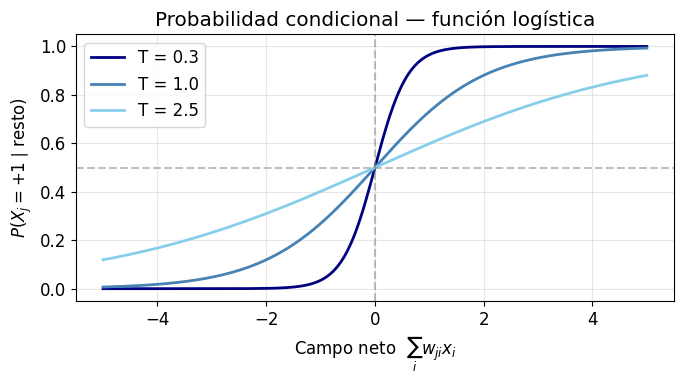

In [15]:
def plot_logistic():
    field_values = np.linspace(-5, 5, 200)
    fig, ax = plt.subplots(figsize=(7, 4))

    for temperature, color in [(0.3, 'navy'), (1.0, 'steelblue'), (2.5, 'skyblue')]:
        p_active = 1 / (1 + np.exp(-field_values / temperature))
        ax.plot(field_values, p_active, color=color, lw=2, label=f"T = {temperature}")

    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(0,   color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel("Campo neto  $\\sum_i w_{ji} x_i$")
    ax.set_ylabel("$P(X_j = +1 \\mid \\text{resto})$")
    ax.set_title("Probabilidad condicional — función logística")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

plot_logistic()

---

## Regla de aprendizaje

$$\Delta w_{ji} = \eta\,(\rho_{ji}^+ - \rho_{ji}^-)$$

- **Correlación empírica** $\rho^+ = \langle x_j x_i \rangle^+$: correlación con visibles **fijados por los datos** — ¿cómo se correlacionan en la realidad?
- **Correlación del modelo** $\rho^- = \langle x_j x_i \rangle^-$: correlación con la red **corriendo libremente** — ¿cómo se correlacionan según el modelo?

**Intuición:**
- $\rho^+ > \rho^-$ → las neuronas se correlacionan más en los datos que en el modelo → subir $w_{ji}$
- $\rho^+ < \rho^-$ → el modelo exagera la correlación → bajar $w_{ji}$
- $\rho^+ = \rho^-$ → el modelo ya aprendió — no cambiar nada

**Limitación:** la fase negativa requiere que la red llegue al equilibrio térmico,
lo cual puede tardar mucho → aprendizaje muy lento.
## Simulación real del aprendizaje

Ahora hacemos la distinción que importa para entrenar: neuronas **visibles** (0, 1) y **ocultas** (2, 3).
Los datos de entrenamiento solo fijan las visibles — para calcular $\rho^+$, se marginalizan las ocultas
con $P(\mathbf{x}_\beta \mid \mathbf{x}_\alpha)$ (exactamente la ec. 11.50).

Definimos patrones donde las neuronas visibles siempre coinciden — esperamos que el modelo aprenda $w_{01} > 0$.

In [16]:
n_visible = 2  # neuronas 0, 1 (visibles)
n_hidden = 2   # neuronas 2, 3 (ocultas)

# Patrones donde las visibles siempre coinciden → ρ⁺_01 = 1
training_data = np.array([[+1, +1],
                           [-1, -1],
                           [+1, +1],
                           [-1, -1]], dtype=float)

print(f"Visibles: neuronas 0, 1 | Ocultas: neuronas 2, 3")
print(f"Configuraciones ocultas: {2**n_hidden}")
print(f"\nDatos ({len(training_data)} patrones, solo visibles):")
print(training_data)

Visibles: neuronas 0, 1 | Ocultas: neuronas 2, 3
Configuraciones ocultas: 4

Datos (4 patrones, solo visibles):
[[ 1.  1.]
 [-1. -1.]
 [ 1.  1.]
 [-1. -1.]]


## compute_clamped_correlations (ρ⁺) y compute_free_correlations (ρ⁻)

- **Correlación empírica** $\rho^+$ — *fase positiva* (visibles clampeadas, ocultas marginalizadas, ec. 11.50):

$$\rho^+_{ji} = \langle x_j x_i \rangle^+ = \frac{1}{|\mathcal{T}|}\sum_{\mathbf{x}_\alpha \in \mathcal{T}} \sum_{\mathbf{x}_\beta} P(\mathbf{X}_\beta = \mathbf{x}_\beta \mid \mathbf{X}_\alpha = \mathbf{x}_\alpha)\, x_j x_i$$

donde $\mathcal{T}$ es el conjunto de entrenamiento, $\mathbf{x}_\alpha$ son los estados de las neuronas **visibles** (fijados por los datos) y $\mathbf{x}_\beta$ son los estados de las neuronas **ocultas** (marginalizadas).

- **Correlación del modelo** $\rho^-$ — *fase negativa* (red corriendo libremente, ec. 11.51):

$$\rho^-_{ji} = \langle x_j x_i \rangle^- = \sum_{\mathbf{x}} P(\mathbf{X} = \mathbf{x})\, x_j x_i$$

In [17]:
def compute_clamped_correlations(data, W, n_visible, temperature=1.0):
    """ρ⁺: fija visibles a datos, marginaliza ocultas (ec. 11.50)."""
    n_total = W.shape[0]
    n_hid = n_total - n_visible
    hidden_states = np.array(list(itertools.product([-1, 1], repeat=n_hid)))

    rho_p = np.zeros_like(W)
    for x_v in data:
        energies = []
        full_states = []
        for x_h in hidden_states:
            x = np.concatenate([x_v, x_h])
            full_states.append(x)
            energies.append(compute_energy(x, W))
        energies = np.array(energies)
        # Misma función usada anteriormente con la distribución de Gibbs
        probs = compute_probabilities(energies, temperature) # P(x_β | x_α)

        # Aca es que se termina de calcular 11.50, este loop representa la doble sumatoria.
        for k, x in enumerate(full_states):
            rho_p += probs[k] * np.outer(x, x)

    rho_p /= len(data)
    np.fill_diagonal(rho_p, 0) # Las máquinas de Boltzmann no permiten auto-retroalimentación
    return rho_p

def compute_free_correlations(W, temperature=1.0):
    """ρ⁻: red corriendo libremente (ec. 11.51)."""
    energies = np.array([compute_energy(s, W) for s in all_states])
    # Misma función usada anteriormente con la distribución de Gibbs
    probs = compute_probabilities(energies, temperature)
    rho_m = np.zeros_like(W)
    for k, x in enumerate(all_states):
        rho_m += probs[k] * np.outer(x, x)
    np.fill_diagonal(rho_m, 0)
    return rho_m

rho_plus = compute_clamped_correlations(training_data, np.zeros((4, 4)), n_visible)
print("ρ⁺ (W=0, ocultas equiprobables):")
print(rho_plus.round(4))

ρ⁺ (W=0, ocultas equiprobables):
[[0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## train_boltzmann

Ejecuta el aprendizaje iterativo con fase positiva y negativa: en cada paso calcula $\rho^+$ (visibles clampeadas, ocultas marginalizadas) y $\rho^-$ (red libre), compara, y actualiza $W$. Retorna el historial de correlaciones y los pesos finales.

In [18]:
def train_boltzmann(data, n_visible, n_steps=150, learning_rate=0.1, temperature=1.0, track_pair=(0, 1)):
    """Entrena con fase positiva (clamped) y negativa (free-running)."""
    n_total = n_visible + n_hidden
    W = np.zeros((n_total, n_total))
    i, j = track_pair

    rho_plus_history = []
    rho_minus_history = []

    for _ in range(n_steps):
        rho_plus = compute_clamped_correlations(data, W, n_visible, temperature)
        rho_minus = compute_free_correlations(W, temperature)

        rho_plus_history.append(rho_plus[i, j])
        rho_minus_history.append(rho_minus[i, j])

        # Δw = η(ρ⁺ - ρ⁻)
        W = W + learning_rate * (rho_plus - rho_minus)
        W = (W + W.T) / 2       # fuerza simetría w_ji = w_ij (ec. 11.37) — no mencionado en el libro, truco numérico
        np.fill_diagonal(W, 0)  # sin auto-retroalimentación (ec. 11.38)

    return rho_plus_history, rho_minus_history, W

rho_plus_history, rho_minus_history, W_learned = train_boltzmann(training_data, n_visible)
print(f"ρ⁺ final (par 0,1): {rho_plus_history[-1]:.4f}")
print(f"ρ⁻ final (par 0,1): {rho_minus_history[-1]:.4f}")
print(f"\nPesos aprendidos:")
print(W_learned.round(3))

ρ⁺ final (par 0,1): 1.0000
ρ⁻ final (par 0,1): 0.9657

Pesos aprendidos:
[[0.    2.027 0.    0.   ]
 [2.027 0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]]


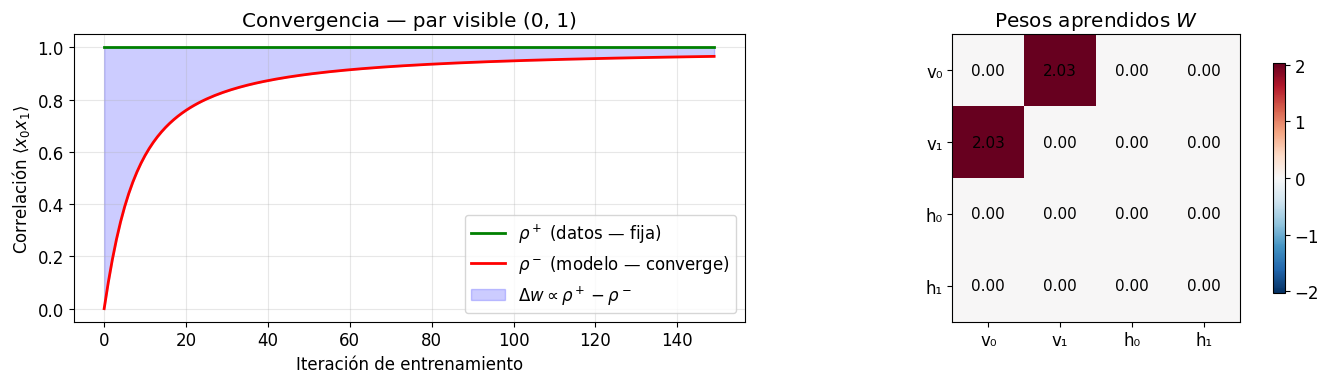

In [19]:
def plot_learning(rho_plus_history, rho_minus_history, W_learned):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Convergencia ρ⁺ → ρ⁻
    steps = np.arange(len(rho_plus_history))
    ax1.plot(steps, rho_plus_history,  'g-', lw=2, label="$\\rho^+$ (datos — fija)")
    ax1.plot(steps, rho_minus_history, 'r-', lw=2, label="$\\rho^-$ (modelo — converge)")
    ax1.fill_between(steps, rho_minus_history, rho_plus_history,
                     where=[rp > rm for rp, rm in zip(rho_plus_history, rho_minus_history)],
                     alpha=0.2, color='blue', label="$\\Delta w \\propto \\rho^+ - \\rho^-$")
    ax1.set_xlabel("Iteración de entrenamiento")
    ax1.set_ylabel("Correlación $\\langle x_0 x_1 \\rangle$")
    ax1.set_title("Convergencia — par visible (0, 1)")
    ax1.legend(); ax1.grid(True, alpha=0.3)

    # Pesos aprendidos
    labels = ['v₀', 'v₁', 'h₀', 'h₁']
    wmax = np.abs(W_learned).max()
    im = ax2.imshow(W_learned, cmap='RdBu_r', vmin=-wmax, vmax=wmax)
    ax2.set_xticks(range(4)); ax2.set_xticklabels(labels)
    ax2.set_yticks(range(4)); ax2.set_yticklabels(labels)
    for i in range(4):
        for j in range(4):
            ax2.text(j, i, f'{W_learned[i,j]:.2f}', ha='center', va='center', fontsize=11)
    ax2.set_title("Pesos aprendidos $W$")
    plt.colorbar(im, ax=ax2, shrink=0.8)

    plt.tight_layout(); plt.show()

plot_learning(rho_plus_history, rho_minus_history, W_learned)

## Conclusión

**Gráfica izquierda — Convergencia:**
- $\rho^+$ (verde) se mantiene en 1.0 desde el inicio: los datos siempre tienen $v_0 = v_1$, por lo que $\langle x_0 x_1 \rangle^+ = 1$ es fijo.
- $\rho^-$ (rojo) arranca en 0 (pesos inicializados en cero → todo equiprobable) y converge hacia $\rho^+$: el modelo aprende a reproducir la correlación de los datos.
- El área azul ($\Delta w \propto \rho^+ - \rho^-$) es la brecha que impulsa la actualización. A medida que $\rho^-$ sube, la brecha se cierra y los pesos dejan de cambiar.

**Gráfica derecha — Pesos aprendidos $W$:**
- $w_{01} = w_{10} = 2.03$: conexión fuertemente excitatoria entre $v_0$ y $v_1$ — exactamente lo esperado, pues las visibles siempre coinciden en los datos.
- Pesos visibles–ocultas ≈ 0: los datos no informan sobre cómo deben correlacionarse las ocultas.

**El modelo aprendió correctamente la única estructura presente en los datos.**

# 7. Redes de Creencia Profundas — DBN


### Métodos Estocásticos y Máquinas de Boltzmann

---

La lentitud de la fase negativa en la Boltzmann machine motivó buscar una arquitectura
más restringida que hiciera la inferencia tratable.

## RBM — Máquina de Boltzmann Restringida

Se eliminan las conexiones **dentro** de cada capa — solo existen conexiones entre la
capa visible y la capa oculta:

![image.png](attachment:c7c18671-56a9-44a4-9d8a-22a2457a9a4c.png)

Capa oculta: Sin conexiones entre ellas
Capa visible: Sin conexiones entre ellas

- **Neuronas visibles** ($v_i$): reciben los datos de entrada (e.g., pixels de una imagen).
- **Neuronas ocultas** ($h_j$): representan características latentes aprendidas de los datos.

**Consecuencia clave:** dado el estado de las neuronas visibles, todas las neuronas ocultas son **condicionalmente independientes** entre sí — y viceversa. Esto permite muestrearlas todas en paralelo en un solo paso, sin esperar equilibrio.

**Regla de aprendizaje:**
$$\frac{\partial L}{\partial w_{ji}} = \rho_{ji}^{(0)} - \rho_{ji}^{(\infty)}$$

Misma forma que Boltzmann clásico. Sin temperatura: Hinton fijó $T = 1$ en la formulación
original — convención adoptada por simplicidad, no una necesidad matemática.

---

## DBN = RBMs apiladas

1. Entrenar RBM sobre datos → features de nivel 1
2. Usar activaciones ocultas como nuevos datos → entrenar otra RBM
3. Repetir → jerarquía de features (features de features)

Cada capa agregada mejora el límite inferior de la log-verosimilitud. Inferencia con un
solo pase bottom-up. Sin supervisión.

**¿Por qué "belief"?** El término viene de las redes Bayesianas y *belief propagation*
(Pearl, años 80): cada nodo representa una creencia probabilística que se actualiza al
recibir información. En las DBN, los nodos ocultos representan **creencias latentes**
sobre la estructura de los datos.

## sigmoid

Función de activación $\sigma(x) = \frac{1}{1+e^{-x}}$. Convierte el campo neto de cada neurona en una probabilidad de activación.

In [20]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

## sample_hidden y sample_visible

En la BM general, calcular $P(\mathbf{h} \mid \mathbf{v})$ requiere sumar sobre todas las configuraciones (intratable). En la RBM, al no haber conexiones intra-capa, la distribución conjunta se **factoriza**:

$$P(\mathbf{h} \mid \mathbf{v}) = \prod_j P(h_j \mid \mathbf{v})$$

Cada factor es simplemente una sigmoide — la $Z$ se cancela igual que en la probabilidad condicional:

$$P(h_j = 1 \mid \mathbf{v}) = \sigma\!\left(\sum_i w_{ji}\, v_i + b_j\right)$$

Esto convierte un problema exponencial ($2^L$ configuraciones ocultas) en $L$ evaluaciones independientes de la sigmoide. Lo mismo aplica en dirección inversa para $P(\mathbf{v} \mid \mathbf{h})$.

- `sample_hidden`: dado el visible, calcula $P(h_j = 1 \mid \mathbf{v})$ con la sigmoide y muestrea.
- `sample_visible`: dado el oculto, calcula $P(v_i = 1 \mid \mathbf{h})$ y muestrea.

In [21]:
def sample_hidden(visible, weights, bias_h):
    """Dado el visible, calcula P(h_j = 1 | v) y muestrea."""
    hidden_probs = sigmoid(visible @ weights + bias_h)
    hidden_states = (np.random.rand(*hidden_probs.shape) < hidden_probs).astype(float)
    return hidden_probs, hidden_states

def sample_visible(hidden, weights, bias_v):
    """Dado el oculto, calcula P(v_i = 1 | h) y muestrea."""
    visible_probs = sigmoid(hidden @ weights.T + bias_v)
    visible_states = (np.random.rand(*visible_probs.shape) < visible_probs).astype(float)
    return visible_probs, visible_states

## reconstruct_visible

Un paso visible → oculto → visible para evaluar la calidad del modelo.

In [22]:
def reconstruct_visible(visible, weights, bias_v, bias_h):
    """Un paso visible → oculto → visible para evaluar calidad."""
    hidden_probs, hidden_states = sample_hidden(visible, weights, bias_h)
    visible_probs, _ = sample_visible(hidden_states, weights, bias_v)
    return visible_probs

## gibbs_sample

Fase negativa: muestreo de Gibbs por bloques (sección 11.6 del libro). Parte de visibles aleatorios y alterna `sample_hidden` → `sample_visible` hasta acercarse al equilibrio. La estructura bipartita de la RBM permite actualizar todas las neuronas de una capa a la vez.

In [23]:
def gibbs_sample(weights, bias_v, bias_h, n_samples, gibbs_steps=50):
    """Muestreo de Gibbs por bloques: alterna hidden ↔ visible hasta equilibrio."""
    n_visible = len(bias_v)
    v = (np.random.rand(n_samples, n_visible) > 0.5).astype(float)
    for _ in range(gibbs_steps):
        _, h = sample_hidden(v, weights, bias_h)
        _, v = sample_visible(h, weights, bias_v)
    h_probs, _ = sample_hidden(v, weights, bias_h)
    return v, h_probs

## train_rbm

Ejecuta el entrenamiento con la regla de Boltzmann: en cada mini-batch, fase positiva (visibles fijados por los datos) → fase negativa (muestreo de Gibbs hasta equilibrio) → $\Delta W = \eta(\rho^+ - \rho^-)$. Retorna los pesos, biases y el historial de errores.

In [24]:
def train_rbm(data, n_visible, n_hidden, epochs=300, learning_rate=0.04, batch_size=16, gibbs_steps=50):
    """Entrena RBM con muestreo de Gibbs para la fase negativa."""
    weights = np.random.randn(n_visible, n_hidden) * 0.01
    bias_v = np.zeros(n_visible)
    bias_h = np.zeros(n_hidden)

    errors = []
    n_data = len(data)
    for _ in range(epochs):
        indices = np.random.permutation(n_data)
        for start in range(0, n_data, batch_size):
            batch = data[indices[start:start + batch_size]]

            # Fase positiva: visibles fijados por los datos
            hidden_probs_pos, _ = sample_hidden(batch, weights, bias_h)
            # Fase negativa: muestreo de Gibbs hasta equilibrio
            v_model, h_probs_neg = gibbs_sample(weights, bias_v, bias_h, len(batch), gibbs_steps)

            # Δw = η(ρ⁺ - ρ⁻)
            n_batch = len(batch)
            weights += learning_rate * (batch.T @ hidden_probs_pos - v_model.T @ h_probs_neg) / n_batch
            bias_v += learning_rate * (batch - v_model).mean(axis=0)
            bias_h += learning_rate * (hidden_probs_pos - h_probs_neg).mean(axis=0)

        errors.append(np.mean((data - reconstruct_visible(data, weights, bias_v, bias_h))**2))

    return weights, bias_v, bias_h, errors

## generate_bar_patterns

Genera 8 patrones binarios de 4×4: 4 barras horizontales (H1–H4) y 4 verticales (V1–V4). Cada patrón se aplana a un vector de 16 elementos para alimentar las 16 neuronas visibles de la RBM.

In [25]:
def generate_bar_patterns(size=4):
    """Genera barras horizontales y verticales como patrones binarios aplanados."""
    patterns = []
    for row in range(size):
        p = np.zeros((size, size)); p[row, :] = 1; patterns.append(p.flatten())
    for col in range(size):
        p = np.zeros((size, size)); p[:, col] = 1; patterns.append(p.flatten())
    return np.array(patterns, dtype=float)

clean_patterns = generate_bar_patterns(size=4)
pattern_names = ['Horizontal 1','Horizontal 2','Horizontal 3','Horizontal 4',
                 'Vertical 1','Vertical 2','Vertical 3','Vertical 4']
for name, pat in zip(pattern_names, clean_patterns):
    print(f"{name}:"); print(pat.reshape(4, 4).astype(int)); print()

Horizontal 1:
[[1 1 1 1]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]

Horizontal 2:
[[0 0 0 0]
 [1 1 1 1]
 [0 0 0 0]
 [0 0 0 0]]

Horizontal 3:
[[0 0 0 0]
 [0 0 0 0]
 [1 1 1 1]
 [0 0 0 0]]

Horizontal 4:
[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [1 1 1 1]]

Vertical 1:
[[1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]]

Vertical 2:
[[0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]]

Vertical 3:
[[0 0 1 0]
 [0 0 1 0]
 [0 0 1 0]
 [0 0 1 0]]

Vertical 4:
[[0 0 0 1]
 [0 0 0 1]
 [0 0 0 1]
 [0 0 0 1]]



## augmented_data

Datos de entrenamiento aumentados: 30 copias de los 8 patrones con ruido gaussiano pequeño ($\sigma = 0.08$). Esto evita que la RBM memorice los patrones exactos y la obliga a aprender la estructura subyacente.

In [26]:
# Augmentación: 30 copias con ruido gaussiano para evitar overfitting
augmented_data = np.vstack([
    np.clip(clean_patterns + 0.08 * np.random.randn(*clean_patterns.shape), 0, 1)
    for _ in range(30)
])
print(f"Patrones originales: {clean_patterns.shape[0]},  Datos aumentados: {augmented_data.shape[0]}")
print()
for name, pat in zip(pattern_names, augmented_data[:8]):
    print(f"{name} (con ruido):"); print(np.round(pat.reshape(4, 4), 2)); print()

Patrones originales: 8,  Datos aumentados: 240

Horizontal 1 (con ruido):
[[1.   0.99 1.   1.  ]
 [0.   0.   0.13 0.06]
 [0.   0.04 0.   0.  ]
 [0.02 0.   0.   0.  ]]

Horizontal 2 (con ruido):
[[0.   0.03 0.   0.  ]
 [1.   0.98 1.   0.89]
 [0.   0.01 0.   0.03]
 [0.   0.   0.   0.15]]

Horizontal 3 (con ruido):
[[0.   0.   0.07 0.  ]
 [0.02 0.   0.   0.02]
 [1.   1.   0.99 0.98]
 [0.   0.   0.   0.08]]

Horizontal 4 (con ruido):
[[0.03 0.   0.03 0.  ]
 [0.   0.05 0.08 0.07]
 [0.   0.   0.03 0.08]
 [0.96 0.99 0.91 0.9 ]]

Vertical 1 (con ruido):
[[1.   0.11 0.   0.08]
 [1.   0.   0.03 0.12]
 [1.   0.13 0.   0.07]
 [1.   0.   0.01 0.  ]]

Vertical 2 (con ruido):
[[0.   1.   0.12 0.  ]
 [0.   0.96 0.07 0.03]
 [0.   1.   0.01 0.08]
 [0.   0.97 0.   0.  ]]

Vertical 3 (con ruido):
[[0.02 0.02 1.   0.  ]
 [0.   0.   0.97 0.  ]
 [0.   0.03 1.   0.01]
 [0.02 0.   0.85 0.  ]]

Vertical 4 (con ruido):
[[0.   0.2  0.   1.  ]
 [0.   0.   0.09 1.  ]
 [0.06 0.   0.11 0.89]
 [0.05 0.18 0.   0.95]]



## Entrenamiento

Creamos una RBM con 16 neuronas visibles (4×4 pixels) y 8 ocultas. Entrenamos 300 épocas con muestreo de Gibbs (50 pasos por fase negativa).

In [27]:
weights, bias_v, bias_h, errors = train_rbm(augmented_data, n_visible=16, n_hidden=8,
                                             epochs=300, learning_rate=0.04,
                                             batch_size=16, gibbs_steps=50)
reconstructions = reconstruct_visible(clean_patterns, weights, bias_v, bias_h)
print(f"Error inicial: {errors[0]:.5f}   Error final: {errors[-1]:.5f}")

Error inicial: 0.19242   Error final: 0.00567


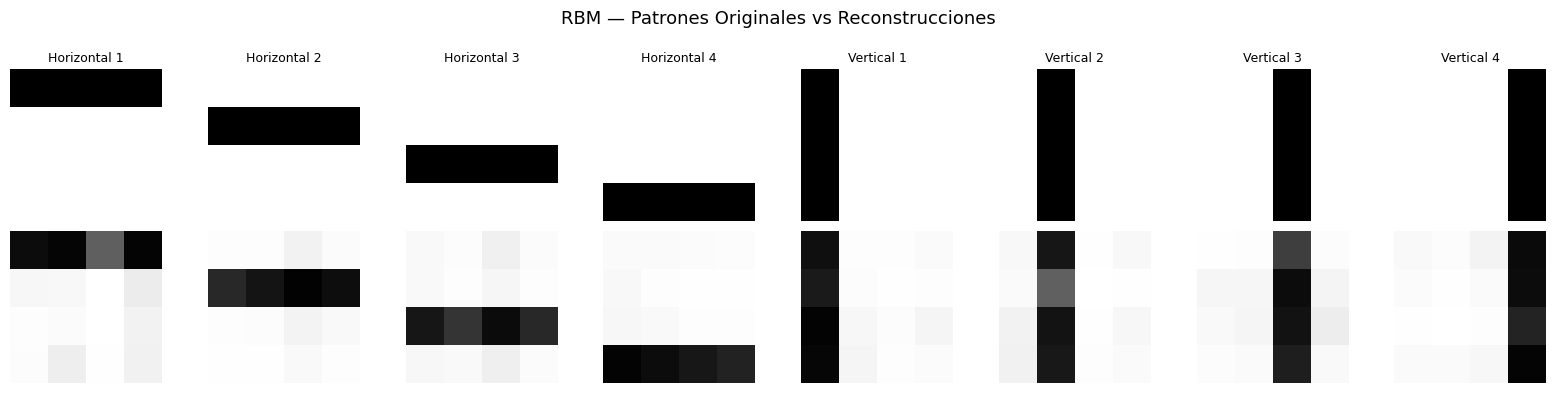

In [28]:
# Visualización: originales vs reconstrucciones
fig, axes_grid = plt.subplots(2, 8, figsize=(16, 4))
pattern_titles = ['Horizontal 1','Horizontal 2','Horizontal 3','Horizontal 4',
                  'Vertical 1','Vertical 2','Vertical 3','Vertical 4']

for idx in range(8):
    axes_grid[0, idx].imshow(clean_patterns[idx].reshape(4, 4),
                              cmap='Greys', vmin=0, vmax=1)
    axes_grid[0, idx].set_title(pattern_titles[idx], fontsize=9)
    axes_grid[0, idx].axis('off')

    axes_grid[1, idx].imshow(reconstructions[idx].reshape(4, 4),
                              cmap='Greys', vmin=0, vmax=1)
    axes_grid[1, idx].axis('off')

axes_grid[0, 0].set_ylabel("Original",       fontsize=10, labelpad=40)
axes_grid[1, 0].set_ylabel("Reconstrucción", fontsize=10, labelpad=40)
plt.suptitle("RBM — Patrones Originales vs Reconstrucciones", fontsize=13)
plt.tight_layout(); plt.show()

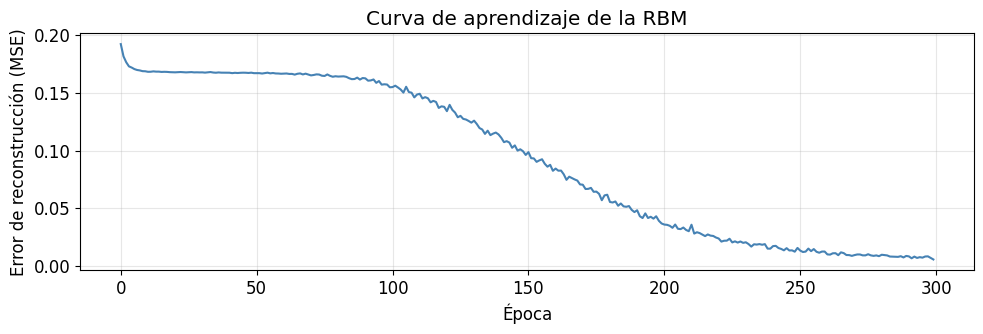

In [29]:
# Curva de aprendizaje
fig_curve, axis_curve = plt.subplots(figsize=(10, 3.5))
axis_curve.plot(errors, color='steelblue', lw=1.5)
axis_curve.set_xlabel("Época"); axis_curve.set_ylabel("Error de reconstrucción (MSE)")
axis_curve.set_title("Curva de aprendizaje de la RBM")
axis_curve.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Referencias
- Haykin, S. (1999). Neural Networks and Learning Machines. Third Edition
- Ising, E. (1925). Beitrag zur Theorie des Ferromagnetismus. Zeitschrift für Physik, 31, 253–258. https://doi.org/10.1007/BF02980577
- Ackley, D. H., Hinton, G. E., & Sejnowski, T. J. (1985). A learning algorithm for Boltzmann machines. Cognitive Science, 9(1), 147–169. https://doi.org/10.1207/s15516709cog0901_7